In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [3]:
# Load and clean data
df = pd.read_csv("../Data/coral_regime.csv", low_memory=False)
df = df.replace('nd', pd.NA)

num_cols = ['Latitude_Degrees','Longitude_Degrees','Depth_m','Percent_Cover','Bleaching_Level',
            'Percent_Bleaching','ClimSST','Temperature_Kelvin','Temperature_Mean',
            'Temperature_Minimum','Temperature_Maximum','Temperature_Kelvin_Standard_Deviation',
            'Windspeed','SSTA','SSTA_Mean','SSTA_Maximum','SSTA_Minimum',
            'TSA','TSA_Mean','TSA_Maximum','TSA_Minimum']

df = df[[c for c in num_cols if c in df.columns]]
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['Percent_Bleaching','Percent_Cover'])

In [4]:
df['Bleaching_Class'] = pd.cut(df['Percent_Bleaching'], bins=[-1,20,50,100], labels=['Low','Medium','High'])
X = df.drop(['Percent_Bleaching','Bleaching_Class'], axis=1)
y = df['Bleaching_Class']

In [5]:
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Bleaching_Level']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

In [8]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train_bal, y_train_bal)
y_pred = rf.predict(X_test)

In [9]:
print("Accuracy:", round(accuracy_score(y_test, y_pred),4))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9813
              precision    recall  f1-score   support

        High       0.89      0.69      0.78        71
         Low       0.99      0.99      0.99      4353
      Medium       0.67      0.74      0.70       111

    accuracy                           0.98      4535
   macro avg       0.85      0.81      0.82      4535
weighted avg       0.98      0.98      0.98      4535



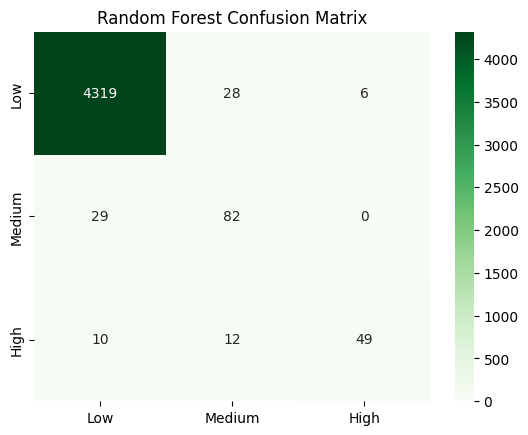

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=['Low','Medium','High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.title("Random Forest Confusion Matrix")
plt.show()


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib

# Compute metrics
results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average='weighted'),
    "Recall": recall_score(y_test, y_pred, average='weighted'),
    "F1": f1_score(y_test, y_pred, average='weighted'),
    "ConfusionMatrix": confusion_matrix(y_test, y_pred, labels=['Low','Medium','High']).tolist()
}

# Save to a file
joblib.dump(results, "rf_results.pkl")
print("Random Forest results saved successfully!")



Random Forest results saved successfully!


In [14]:
import joblib

# Save trained Random Forest model
joblib.dump(rf, "rf_model.pkl")

# Save the scaler and imputer as well
joblib.dump(scaler, "scaler.pkl")
joblib.dump(imputer, "imputer.pkl")
joblib.dump(num_cols, "num_cols.pkl")
joblib.dump(X_train, "x_train_model.pkl")


['x_train_model.pkl']